In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from rdkit import Chem
from rdkit.Chem import rdFMCS, Draw

plt.style.use('default')
sns.set_palette("husl")

In [3]:
def set_plot_style():
    """Set clean plotting style similar to GPG style."""
    plt.rcParams.update({
        "figure.figsize": (3.5, 3.2),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.linewidth": 1.0,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.visible": False,
        "ytick.minor.visible": False,
        "axes.grid": False,
        "legend.frameon": False,
    })



In [4]:
working_dir = os.getcwd() 

In [5]:
new_data_dir = f'{working_dir}/data/new_rates'
new_scope_filename = f'hte_rates_drug_scope'
new_scope = pd.read_csv(f'{new_data_dir}/{new_scope_filename}.csv')
new_scope['is_biased'] = new_scope['Slow_unreliable'] == True
new_scope['bias'] = np.where(new_scope['is_biased'], new_scope['Controls']*1.5 - new_scope['HTE_rate'], 0)
print(new_scope.shape)

(11, 16)


In [6]:
from build_class_and_bias_models.src.data_processing import load_and_process_features
from build_class_and_bias_models.src.model_building import create_combined_dataset

acid_feature_data, amine_feature_data = load_and_process_features(new_scope)

key_features = ['amine_class_1_mixture', 
                'acyl_class_aromatic', 
                'acyl_Charges_secondary_1', 
                'amine_Charges_secondary_1', 
                'acyl_pka_aHs_x_has_acidic_H', 
                'amine_pka_basic', 
                'acyl_BV_secondary_2', 
                'amine_BV_secondary_avg']

combined_df, _ = create_combined_dataset(acid_feature_data, amine_feature_data, new_scope, key_features, save_df=False)
print(combined_df.shape)
combined_df.head()

Found 5 hydrogen-dependent features: ['num_Hs', 'BV_Hs_avg', 'Charges_Hs_avg', 'fukui_E_Hs_avg', 'fukui_N_Hs_avg']
Found 2 pKa-dependent features: ['pka_aHs', 'pka_lowest']
Found 26 heteroatom-dependent features: ['BV_main_1', 'Charges_main_atom', 'fukui_E_main_atom', 'fukui_N_main_atom', 'L_main_atom_1', 'L_main_atom_2', 'B1_main_atom_1', 'B1_main_atom_2', 'B5_main_atom_1', 'B5_main_atom_2', 'Charges_secondary_1', 'Charges_secondary_2', 'fukui_N_secondary_1', 'fukui_N_secondary_2', 'Charges_secondary_avg', 'fukui_N_secondary_avg', 'FCS_1', 'FREQS_1', 'FCS_2', 'FREQS_2', 'FCS_avg', 'FREQS_avg', 'BV_Hs_avg', 'Charges_Hs_avg', 'fukui_E_Hs_avg', 'fukui_N_Hs_avg']

Processing num_Hs conditional features...
  18/46 molecules meet condition num_Hs
    num_Hs: 0 -> 0 NA values
    BV_Hs_avg: 28 -> 0 NA values
    Charges_Hs_avg: 28 -> 0 NA values
    fukui_E_Hs_avg: 28 -> 0 NA values
    fukui_N_Hs_avg: 28 -> 0 NA values

Processing pKa_features conditional features...
  18/46 molecules meet 

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,is_biased,bias,acyl_class_aromatic,acyl_Charges_secondary_1,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg
0,rxn_07_54,7,54,16.838853,0.0,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,ClC(=O)c1sccc1,...,False,0.0,False,-0.180260,0.0,114.114473,False,-0.026113,9.42,65.397280
1,rxn_22_54,22,54,1.092647,0.0,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CCCCC(CC)C(Cl)=O,...,False,0.0,False,-0.193535,14.8,115.811976,False,-0.026113,9.42,65.397280
2,rxn_07_55,7,55,16.838853,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)c1sccc1,...,False,0.0,False,-0.180260,0.0,114.114473,False,0.007275,9.31,82.199216
3,rxn_22_55,22,55,1.092647,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCC(CC)C(Cl)=O,...,False,0.0,False,-0.193535,14.8,115.811976,False,0.007275,9.31,82.199216
4,rxn_25_55,25,55,368.625181,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCCCCCCCCC(Cl)=O,...,False,0.0,False,-0.191172,14.9,85.361508,False,0.007275,9.31,82.199216


In [7]:
combined_csv = f"{new_data_dir}/combined_features_{new_scope_filename}.csv"
combined_df.to_csv(combined_csv, index=False)

# Individual predictions

In [9]:
from build_class_and_bias_models.src.load_models import load_models_simple

# Load all models with the same suffix
predictor = load_models_simple("_each_8_1_optuna")

# Make predictions
n = -1
feature_data = combined_df[key_features].iloc[n].to_dict()
predicted_bias = predictor.predict_bias(feature_data)
predicted_class = predictor.predict_rate_class(feature_data)

print(f"\nPredictions for {combined_df.iloc[n]['reaction']}")
print(f"Predicted class: {predicted_class}")
if predicted_class == 1:
    print("This is a fast instant reaction!! (Unmeasurable)")
else:
    print("This is a measurable reaction")
    print(f"Predicted bias: {predicted_bias}")


Error loading models: [Errno 2] No such file or directory: 'models/best_classifier_each_8_1_optuna.pkl'
Make sure you've trained and saved models first
Expected files:
  models/best_classifier_each_8_1_optuna.pkl
  models/scaler_class_each_8_1_optuna.pkl
  models/best_regressor_each_8_1_optuna.pkl
  models/scaler_reg_each_8_1_optuna.pkl
  models/features_each_8_1_optuna.pkl
Models not loaded. Cannot make predictions.
Classifier not loaded. Cannot make predictions.

Predictions for rxn_31_55
Predicted class: 0
This is a measurable reaction
Predicted bias: 0.0


# Predictions in Batches

In [11]:
from build_class_and_bias_models.src.load_models import load_and_predict_batch

# Process entire CSV files
results = load_and_predict_batch(
    combined_csv,
    classifier_suffix='_each_8_1_optuna',
    regressor_suffix='_each_8_1_optuna',
    features_suffix='_each_8_1_optuna',
    save_results=True
)

Loaded 11 rows from /Users/liliana/Research/CMU/Isayev/Projects/Collaborations/Bernhard_Amide-coupling/Publish/PRISM/data/new_rates/combined_features_hte_rates_drug_scope.csv
Error loading models: [Errno 2] No such file or directory: 'models/best_classifier_each_8_1_optuna.pkl'
Make sure you've trained and saved models first
Expected files:
  models/best_classifier_each_8_1_optuna.pkl
  models/scaler_class_each_8_1_optuna.pkl
  models/best_regressor_each_8_1_optuna.pkl
  models/scaler_reg_each_8_1_optuna.pkl
  models/features_each_8_1_optuna.pkl
Failed to load models


# Visualize Results

In [12]:
preds = pd.read_csv(f"{combined_csv.split('.')[0]}_with_predictions.csv")
preds['HTE_rate_corr'] = preds['HTE_rate'] - preds['predicted_bias']
preds.tail(10)

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,acyl_Charges_secondary_1,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg,predicted_bias,predicted_class,HTE_rate_corr
1,rxn_22_54,22,54,1.092647,0.00,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,-0.026113,9.42,65.397280,0.000000,1,0.000000
2,rxn_07_55,7,55,16.838853,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)c1sccc1,...,-0.180260,0.0,114.114473,False,0.007275,9.31,82.199216,0.000000,1,0.000000
3,rxn_22_55,22,55,1.092647,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,0.007275,9.31,82.199216,0.000000,1,0.000000
4,rxn_25_55,25,55,368.625181,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCCCCCCCCC(Cl)=O,...,-0.191172,14.9,85.361508,False,0.007275,9.31,82.199216,0.000000,1,0.000000
5,rxn_07_56,7,56,16.838853,154.66,False,False,2.189378,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,ClC(=O)c1sccc1,...,-0.180260,0.0,114.114473,False,0.045874,8.40,100.446591,17.202915,0,137.457085
6,rxn_14_56,14,56,518.871701,0.00,False,True,NaN,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,CC(Cl)=O,...,-0.189124,14.6,48.659668,False,0.045874,8.40,100.446591,219.535440,0,-219.535440
7,rxn_22_56,22,56,1.092647,3.70,False,False,0.568202,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,0.045874,8.40,100.446591,19.637338,0,-15.937338
8,rxn_03_54,3,54,3.638350,0.00,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CC(C)(C)c1ccc(cc1)C(Cl)=O,...,-0.196040,0.0,112.496459,False,-0.026113,9.42,65.397280,0.000000,1,0.000000
9,rxn_10_54,10,54,3.740117,0.00,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CC(C)(C)C(Cl)=O,...,-0.194645,0.0,116.759566,False,-0.026113,9.42,65.397280,0.000000,1,0.000000
10,rxn_31_55,31,55,3.349492,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)C12CC3CC(CC(C3)C1)C2,...,-0.200922,0.0,139.407585,False,0.007275,9.31,82.199216,0.000000,0,0.000000


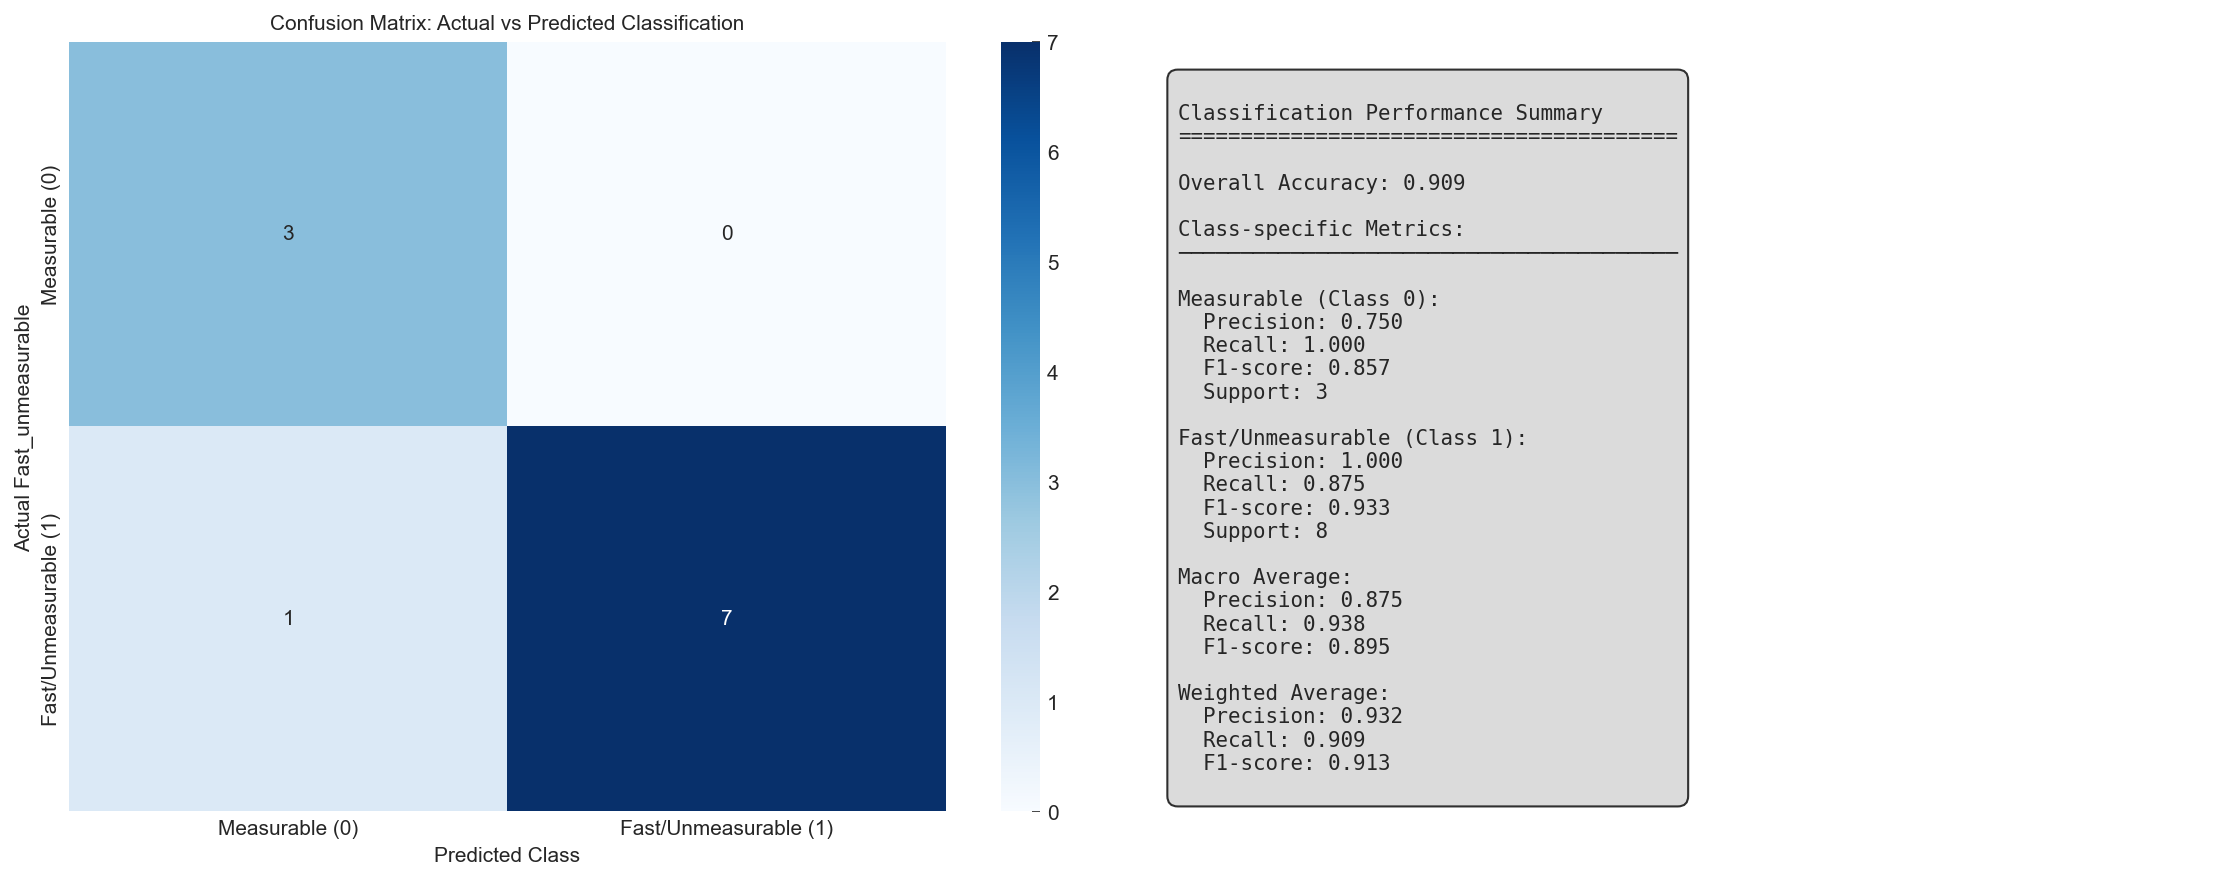


Detailed Classification Report:
                   precision    recall  f1-score   support

       Measurable       0.75      1.00      0.86         3
Fast/Unmeasurable       1.00      0.88      0.93         8

         accuracy                           0.91        11
        macro avg       0.88      0.94      0.90        11
     weighted avg       0.93      0.91      0.91        11


Misclassification Analysis:
Total misclassified: 1 out of 11 (9.1%)


In [13]:
set_plot_style()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#### Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(preds['Fast_unmeasurable'], preds['predicted_class'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Measurable (0)', 'Fast/Unmeasurable (1)'],
            yticklabels=['Measurable (0)', 'Fast/Unmeasurable (1)'])
ax1.set_title('Confusion Matrix: Actual vs Predicted Classification')
ax1.set_xlabel('Predicted Class')
ax1.set_ylabel('Actual Fast_unmeasurable')

ax2 = axes[1]
ax2.axis('off')


accuracy = np.mean(preds['Fast_unmeasurable'] == preds['predicted_class'])
report = classification_report(preds['Fast_unmeasurable'], preds['predicted_class'], 
                             target_names=['Measurable', 'Fast/Unmeasurable'], 
                             output_dict=True)

#### Summary
metrics_text = f"""
Classification Performance Summary
{'='*40}

Overall Accuracy: {accuracy:.3f}

Class-specific Metrics:
{'─'*40}

Measurable (Class 0):
  Precision: {report['Measurable']['precision']:.3f}
  Recall: {report['Measurable']['recall']:.3f}
  F1-score: {report['Measurable']['f1-score']:.3f}
  Support: {int(report['Measurable']['support'])}

Fast/Unmeasurable (Class 1):
  Precision: {report['Fast/Unmeasurable']['precision']:.3f}
  Recall: {report['Fast/Unmeasurable']['recall']:.3f}
  F1-score: {report['Fast/Unmeasurable']['f1-score']:.3f}
  Support: {int(report['Fast/Unmeasurable']['support'])}

Macro Average:
  Precision: {report['macro avg']['precision']:.3f}
  Recall: {report['macro avg']['recall']:.3f}
  F1-score: {report['macro avg']['f1-score']:.3f}

Weighted Average:
  Precision: {report['weighted avg']['precision']:.3f}
  Recall: {report['weighted avg']['recall']:.3f}
  F1-score: {report['weighted avg']['f1-score']:.3f}
"""

ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.show()


print("\nDetailed Classification Report:")
print("="*50)
print(classification_report(preds['Fast_unmeasurable'], preds['predicted_class'], 
                          target_names=['Measurable', 'Fast/Unmeasurable']))

# Additional analysis: misclassified reactions
print("\nMisclassification Analysis:")
print("="*30)
misclassified = preds[preds['Fast_unmeasurable'] != preds['predicted_class']]
print(f"Total misclassified: {len(misclassified)} out of {len(preds)} ({len(misclassified)/len(preds)*100:.1f}%)")

In [14]:
misclassified['rxn_smiles'] = misclassified['amine_smiles'] + '.' + misclassified['acid_smiles']
misclassified.head()

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg,predicted_bias,predicted_class,HTE_rate_corr,rxn_smiles
10,rxn_31_55,31,55,3.349492,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)C12CC3CC(CC(C3)C1)C2,...,0.0,139.407585,False,0.007275,9.31,82.199216,0.0,0,0.0,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...


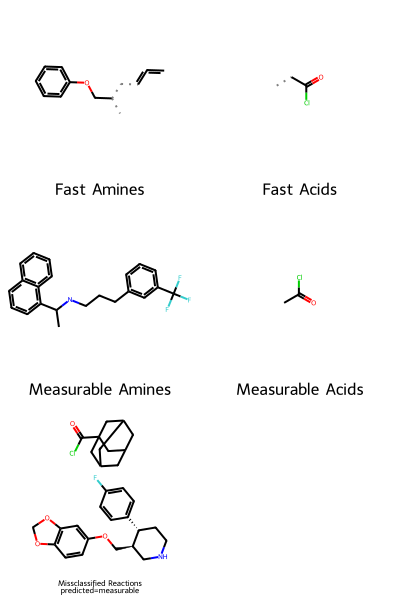

In [15]:
fast_mols_amines = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == True]['amine_smiles']]
fast_mols_acids = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == True]['acid_smiles']]

measurables_mols_amines = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == False]['amine_smiles']]
measurables_mols_acids = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == False]['acid_smiles']]

missclassified_mols_rxn = [Chem.MolFromSmiles(sm) for sm in misclassified['rxn_smiles']]
missclassified_preds = [ "measurable" if missclass == 0 else "fast" for missclass in misclassified['predicted_class']]

# Find the Maximum Common Substructure (MCS)
all_mols = [fast_mols_amines, fast_mols_acids, measurables_mols_amines, measurables_mols_acids]
mcs_mols = []
for i, mols in enumerate(all_mols):
    res = rdFMCS.FindMCS(mols)
    mcs_smarts = res.smartsString
    mcs_mol = Chem.MolFromSmarts(mcs_smarts)
    mcs_mols.append(mcs_mol)
    
    
Draw.MolsToGridImage(mcs_mols+missclassified_mols_rxn, molsPerRow=2, subImgSize=(200,200), 
                     legends=['Fast Amines', 
                              'Fast Acids', 
                              'Measurable Amines', 
                              'Measurable Acids', 
                              f'Missclassified Reactions\npredicted={missclassified_preds[len(missclassified_preds)-1]}'])